# 전체 데이터 + A그룹(소화기관·대사) 분석

In [1]:
!apt-get update -qq
!apt-get install -y fonts-nanum -qq > /dev/null
!fc-cache -fv > /dev/null
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal, chisquare, linregress

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 및 A그룹 추출
df = pd.read_csv('/content/FDA_adverse_events_final.csv', encoding='utf-8')
df_A = df[df['WHO_ATC'] == 'A'].copy()
df_A['receive_date'] = pd.to_datetime(df_A['receive_date'], format='%Y-%m-%d')
df_A['quarter'] = df_A['receive_date'].dt.to_period('Q')  # 분기별

# 적응증(투약 사유)컬럼명
INDI_COL = 'drug_indication'

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


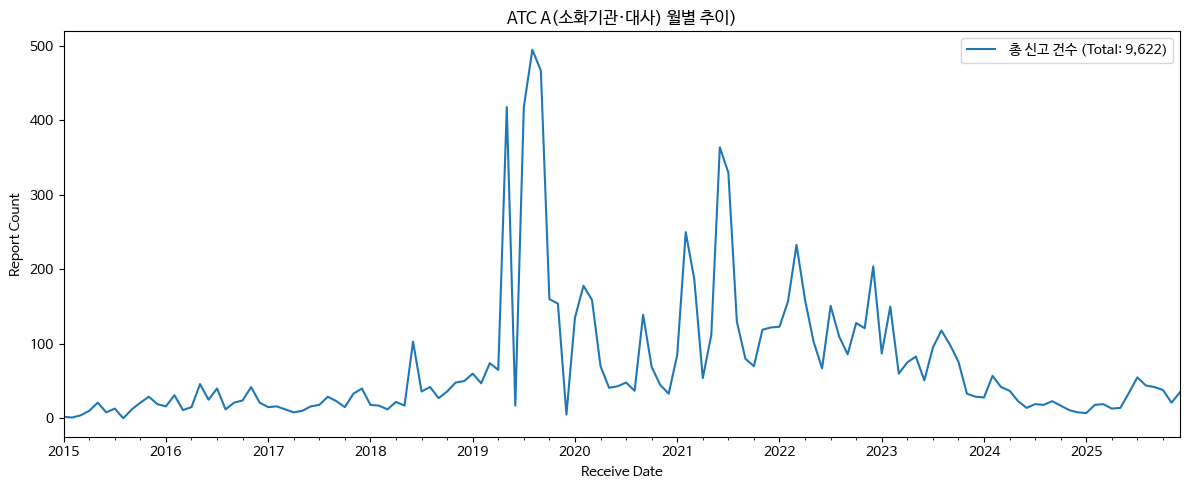

In [2]:
# 시간 흐름별 추세 확인 (월별)
monthly = df_A.set_index('receive_date').resample('ME').size()
total_count = monthly.sum()
fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(ax=ax, label=f' 총 신고 건수 (Total: {total_count:,})')
ax.set_title('ATC A(소화기관·대사) 월별 추이)')
ax.set_xlabel('Receive Date')
ax.set_ylabel('Report Count')
ax.legend()
plt.tight_layout()
plt.show()

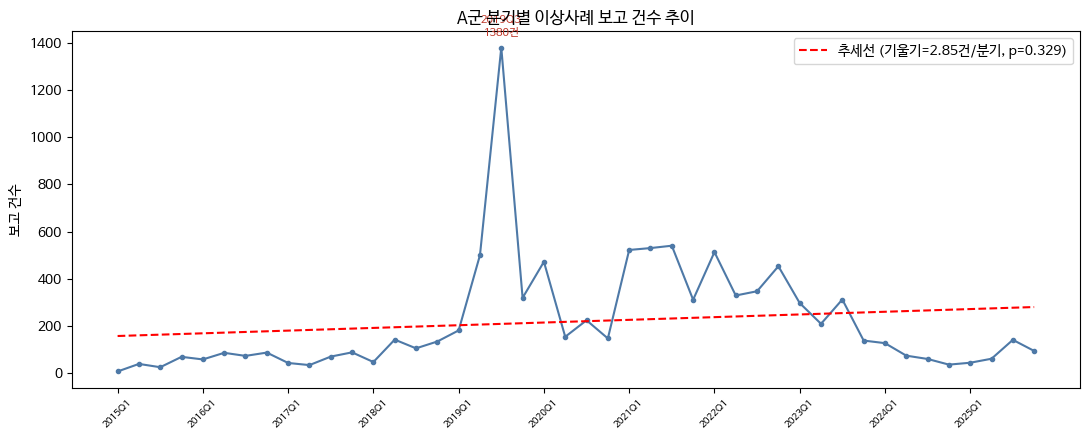

In [3]:
# 분기별 추이 + Mann-Kendall 추세 검정
q = df_A.groupby('quarter').size().sort_index()
x = np.arange(len(q))
slope, intercept, r, p_lin, se = linregress(x, q.values)

try:
    import pymannkendall as mk
    mkres = mk.original_test(q.values)
    mk_txt = f"S={mkres.s}, z={mkres.z:.2f}, p={mkres.p:.3f}, trend={mkres.trend}"
    mk_p = mkres.p
except ImportError:
    n = len(q.values); s = 0
    for i in range(n-1):
        for j in range(i+1, n): s += np.sign(q.values[j] - q.values[i])
    mk_txt = f"S={s} (pip install pymannkendall 권장)"; mk_p = None

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(x, q.values, marker='o', ms=3, color='#4e79a7')
ax.plot(x, intercept + slope*x, '--', color='red',
        label=f'추세선 (기울기={slope:.2f}건/분기, p={p_lin:.3f})')
peak_i = int(np.argmax(q.values))
ax.annotate(f'{q.index[peak_i]}\n{q.values[peak_i]}건', (peak_i, q.values[peak_i]),
            textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8, color='#c0392b')
ax.set_xticks(x[::4]); ax.set_xticklabels(q.index[::4], rotation=45, fontsize=7)
ax.set_ylabel('보고 건수'); ax.set_title('A군 분기별 이상사례 보고 건수 추이')
ax.legend()
plt.tight_layout(); plt.show()

2019 하반기에 급증함 해당 관련 이슈가 발생했을 가능성이 있음 .
> 특정 브랜드의 이슈 , 특정 성분의 이슈 등 ..
2025년

n=6707, chi2=1220.62, dof=9, p=4.28e-257, Cramér's V=0.427, 기대빈도최소=2.3


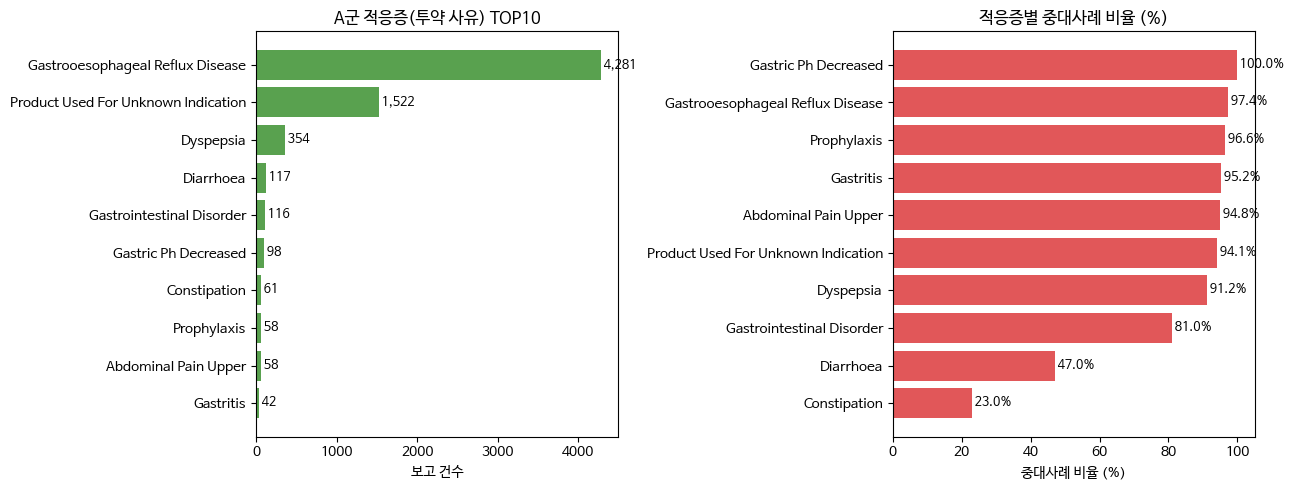

In [4]:
# 적응증(투약사유) Top10 x 중대사례
excl = ['unknown', 'Unknown', 'UNKNOWN', 'not applicable', 'Not Applicable', np.nan]
indi_valid = df_A[~df_A[INDI_COL].isin(excl)].copy()
top10_indi = indi_valid[INDI_COL].value_counts().head(10).index.tolist()
sub = indi_valid[indi_valid[INDI_COL].isin(top10_indi)].copy()

ct = pd.crosstab(sub[INDI_COL], sub['serious'])
chi2, p, dof, exp = chi2_contingency(ct)
n = ct.values.sum()
cv = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"n={n}, chi2={chi2:.2f}, dof={dof}, p={p:.3g}, Cramér's V={cv:.3f}, 기대빈도최소={exp.min():.1f}")

serious_by_indi = (sub.groupby(INDI_COL)['serious']
                    .apply(lambda s: (s == 'Yes').mean())
                    .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

indi_counts = indi_valid[INDI_COL].value_counts().head(10)
axes[0].barh(indi_counts.index[::-1], indi_counts.values[::-1], color='#59a14f')
axes[0].set_title('A군 적응증(투약 사유) TOP10')
axes[0].set_xlabel('보고 건수')
for i, v in enumerate(indi_counts.values[::-1]):
    axes[0].text(v, i, f' {v:,}', va='center', fontsize=9)

order = serious_by_indi.index
axes[1].barh(order[::-1], (serious_by_indi.values * 100)[::-1], color='#e15759')
axes[1].set_title('적응증별 중대사례 비율 (%)')
axes[1].set_xlabel('중대사례 비율 (%)')
for i, v in enumerate((serious_by_indi.values * 100)[::-1]):
    axes[1].text(v, i, f' {v:.1f}%', va='center', fontsize=9)

plt.tight_layout(); plt.show()

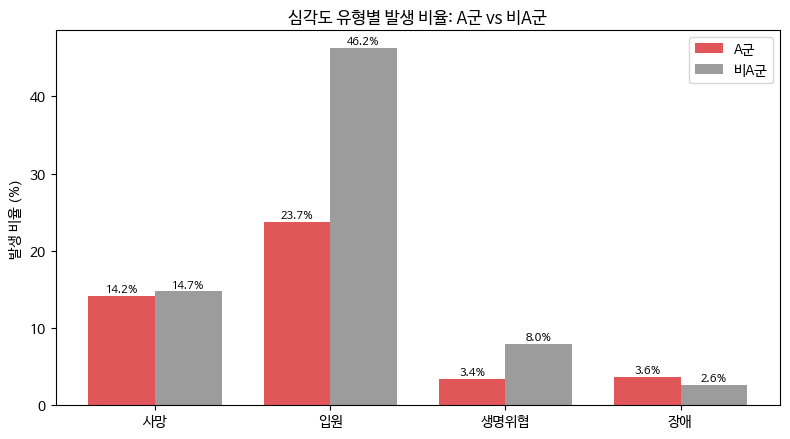

In [5]:
# 비A군 포함한 전체 df 필요 (df_A 아님!)
df['grp'] = np.where(df['WHO_ATC'] == 'A', 'A군', '비A군')

labels = {'is_fatal': '사망', 'is_hospitalized': '입원',
          'is_life_threat': '생명위협', 'is_disabling': '장애'}

A_rates = [df[df.grp == 'A군'][o].mean() * 100 for o in labels]
N_rates = [df[df.grp == '비A군'][o].mean() * 100 for o in labels]

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, A_rates, w, label='A군', color='#e15759')
ax.bar(x + w/2, N_rates, w, label='비A군', color='#9c9c9c')
for i, (a, n) in enumerate(zip(A_rates, N_rates)):
    ax.text(i - w/2, a + 0.5, f'{a:.1f}%', ha='center', fontsize=8)
    ax.text(i + w/2, n + 0.5, f'{n:.1f}%', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels.values())
ax.set_ylabel('발생 비율 (%)')
ax.set_title('심각도 유형별 발생 비율: A군 vs 비A군')
ax.legend()
plt.tight_layout(); plt.show()

In [6]:
# 전체 중대사례 통계검정: A vs 비A
print("[전체 중대사례] A vs 비A")
ct = pd.crosstab(df['grp'], df['serious'])
chi2, p, dof, _ = chi2_contingency(ct)
v = (chi2 / ct.values.sum()) ** 0.5
a = (df[df.grp=='A군']['serious']=='Yes').mean()*100
n = (df[df.grp=='비A군']['serious']=='Yes').mean()*100
print(f"A군 {a:.2f}% vs 비A군 {n:.2f}%  chi2={chi2:.2f}, p={p:.3g}, Cramér's V={v:.3f}\n")

for oc, lab in labels.items():
    ct = pd.crosstab(df['grp'], df[oc])
    chi2, p, dof, _ = chi2_contingency(ct)
    a = df[df.grp=='A군'][oc].mean()*100; n = df[df.grp=='비A군'][oc].mean()*100
    sig = '유의' if p < 0.05 else '무의미'
    print(f"[{lab}] chi2={chi2:.2f}, p={p:.3g} ({sig})  A={a:.2f}% vs 비A={n:.2f}%")

[전체 중대사례] A vs 비A
A군 93.37% vs 비A군 76.88%  chi2=1001.22, p=9.74e-220, Cramér's V=0.234

[사망] chi2=1.21, p=0.272 (무의미)  A=14.16% vs 비A=14.74%
[입원] chi2=1026.17, p=3.69e-225 (유의)  A=23.70% vs 비A=46.25%
[생명위협] chi2=183.97, p=6.57e-42 (유의)  A=3.36% vs 비A=7.96%
[장애] chi2=14.77, p=0.000121 (유의)  A=3.62% vs 비A=2.61%


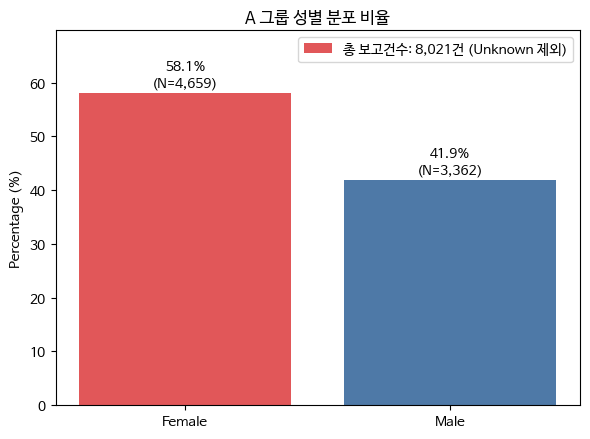

In [7]:
# A그룹 내 성별 분포 비율/수 확인 (Unknown 제외)
sex_df = df_A[df_A['patient_sex'].isin(['Male', 'Female'])]
sex_dist = pd.DataFrame({'Count': sex_df['patient_sex'].value_counts(),
                          'Percent (%)': (sex_df['patient_sex'].value_counts(normalize=True) * 100).round(1)})
total_sex = sex_dist['Count'].sum()

color_map = {'Female': '#e15759', 'Male': '#4e79a7'}
colors = [color_map[s] for s in sex_dist.index]
fig, ax = plt.subplots(figsize=(6,4.5))
bars = ax.bar(sex_dist.index, sex_dist['Percent (%)'], color=colors,
              label=f'총 보고건수: {total_sex:,}건 (Unknown 제외)')
for bar, count, pct in zip(bars, sex_dist['Count'], sex_dist['Percent (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%\n(N={count:,})', ha='center', va='bottom', fontsize=10)
ax.set_title('A 그룹 성별 분포 비율')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, sex_dist['Percent (%)'].max() * 1.2)
ax.legend()
plt.tight_layout()
plt.show()

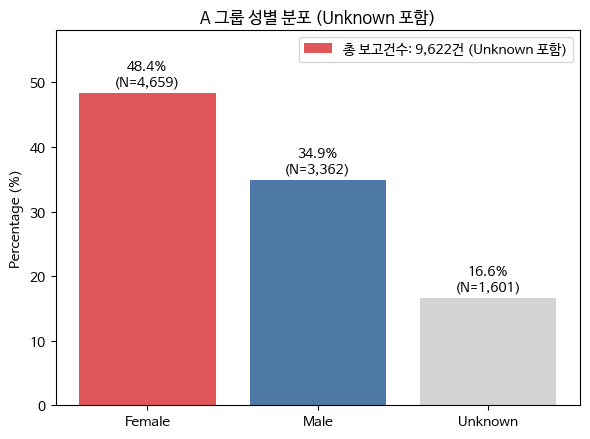

In [8]:
# 성별 분포 (Unknown 포함)
sex_order = ['Female', 'Male', 'Unknown']
sex_dist = (df_A['patient_sex'].replace({np.nan: 'Unknown'}).value_counts().reindex(sex_order, fill_value=0))
sex_dist = pd.DataFrame({'Count': sex_dist, 'Percent (%)': (sex_dist / len(df_A) * 100).round(1)})
total_sex_all = sex_dist['Count'].sum()
color_map = {'Female': '#e15759', 'Male': '#4e79a7', 'Unknown': 'lightgray'}
colors = [color_map[s] for s in sex_dist.index]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(sex_dist.index, sex_dist['Percent (%)'], color=colors,
              label=f'총 보고건수: {total_sex_all:,}건 (Unknown 포함)')
for bar, count, pct in zip(bars, sex_dist['Count'], sex_dist['Percent (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%\n(N={count:,})', ha='center', va='bottom', fontsize=10)
ax.set_title('A 그룹 성별 분포 (Unknown 포함)')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, sex_dist['Percent (%)'].max()*1.2)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# 결과 변수의 발생률/통계 검정을 위한 공통 함수
def rate_tab(data, col, outcome):
    t = data.groupby(col)[outcome].agg(['mean', 'count'])
    t['rate'] = (t['mean'] * 100).round(1)
    return t

def test_association(data, group_col, outcome_col):
    """
    group_col(성별)과 outcome_col(사망) 사이에 통계적 연관이 있는지 검정.
    - 카이제곱: 연관이 '있는지' (유의성)
    - Cramér's V: 연관이 '얼마나 센지' (효과크기)
    - 오즈비: 2x2일 때 '방향과 크기' (몇 배인지)
    """
    obs = pd.crosstab(data[group_col], data[outcome_col])
    chi2, p, dof, expected = chi2_contingency(obs)
    n = obs.values.sum()
    k = min(obs.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k))

    print(f"── {group_col} vs {outcome_col} ──")
    print("교차표(관측):")
    print(obs, "\n")
    print(f"기대빈도 최소값: {expected.min():.1f}  (5 이상이어야 카이제곱 신뢰 가능)")
    print(f"카이제곱  chi2 = {chi2:.3f},  dof = {dof},  p = {p:.3g}")
    print(f"효과크기  Cramér's V = {cramers_v:.3f}")

    if obs.shape == (2, 2):
        (r0, r1), (c0, c1) = obs.index, obs.columns
        a, b = obs.loc[r1, c1], obs.loc[r1, c0]
        c, d = obs.loc[r0, c1], obs.loc[r0, c0]
        OR = (a * d) / (b * c)
        print(f"오즈비   OR({r1} vs {r0}, {c1}) = {OR:.2f}")

    print(f"\n판정: p {'<' if p < 0.05 else '>='} 0.05 → "
          f"{'연관 있음(귀무가설 기각)' if p < 0.05 else '연관 있다고 보기 어려움'}")
    return {'chi2': chi2, 'p': p, 'dof': dof, 'cramers_v': cramers_v}

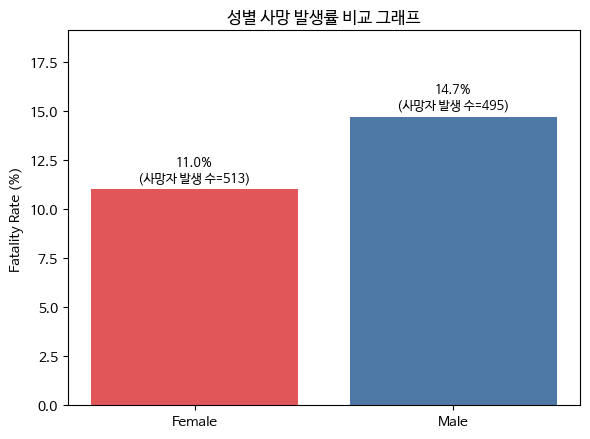

In [10]:
# 성별별 사망 발생률 비교 그래프 - 카이제곱 사용
t = rate_tab(sex_df, 'patient_sex', 'is_fatal')
_, p, _, _ = chi2_contingency(pd.crosstab(sex_df['patient_sex'], sex_df['is_fatal']))

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(t.index, t['rate'], color=['#e15759', '#4e79a7'])
death_count = (sex_df[sex_df['is_fatal'] == True].groupby('patient_sex').size().reindex(t.index, fill_value=0))
for b, death in zip(bars, death_count):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f"{b.get_height():.1f}%\n(사망자 발생 수={death:,})", ha='center', va='bottom', fontsize=9)
ax.set_title('성별 사망 발생률 비교 그래프')
ax.set_ylabel('Fatality Rate (%)'); ax.set_ylim(0, t['rate'].max()*1.3)
plt.tight_layout(); plt.show()

In [11]:
test_association(sex_df, 'patient_sex', 'is_fatal')

── patient_sex vs is_fatal ──
교차표(관측):
is_fatal     False  True 
patient_sex              
Female        4146    513
Male          2867    495 

기대빈도 최소값: 422.5  (5 이상이어야 카이제곱 신뢰 가능)
카이제곱  chi2 = 24.158,  dof = 1,  p = 8.87e-07
효과크기  Cramér's V = 0.055
오즈비   OR(Male vs Female, True) = 1.40

판정: p < 0.05 → 연관 있음(귀무가설 기각)


{'chi2': np.float64(24.157968250370573),
 'p': np.float64(8.874820147555006e-07),
 'dof': 1,
 'cramers_v': np.float64(0.054880232793090754)}

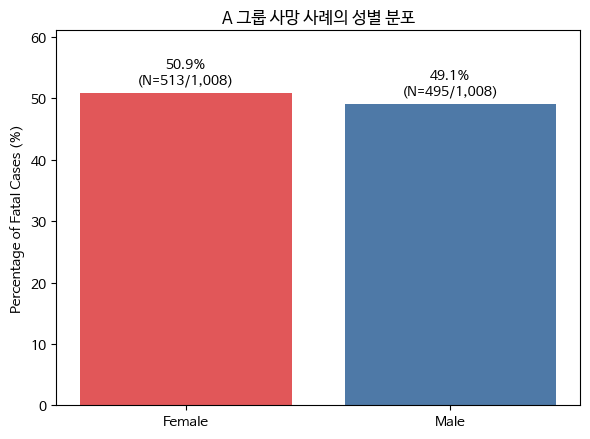

In [12]:
# 사망 사례의 성별 분포
death_df = df_A[(df_A['is_fatal'] == True) & (df_A['patient_sex'].isin(['Female', 'Male']))]
sex_dist = pd.DataFrame({
    'Count': death_df['patient_sex'].value_counts().reindex(['Female', 'Male']),
    'Percent (%)': (death_df['patient_sex'].value_counts(normalize=True).reindex(['Female', 'Male']) * 100).round(1)
})
color_map = {'Female': '#e15759', 'Male': '#4e79a7'}
colors = [color_map[s] for s in sex_dist.index]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(sex_dist.index, sex_dist['Percent (%)'], color=colors)
total_deaths = sex_dist['Count'].sum()
for bar, count, pct in zip(bars, sex_dist['Count'], sex_dist['Percent (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{pct:.1f}%\n(N={count:,}/{total_deaths:,})', ha='center', va='bottom', fontsize=10)
ax.set_title('A 그룹 사망 사례의 성별 분포')
ax.set_ylabel('Percentage of Fatal Cases (%)')
ax.set_ylim(0, sex_dist['Percent (%)'].max()*1.2)
plt.tight_layout()
plt.show()

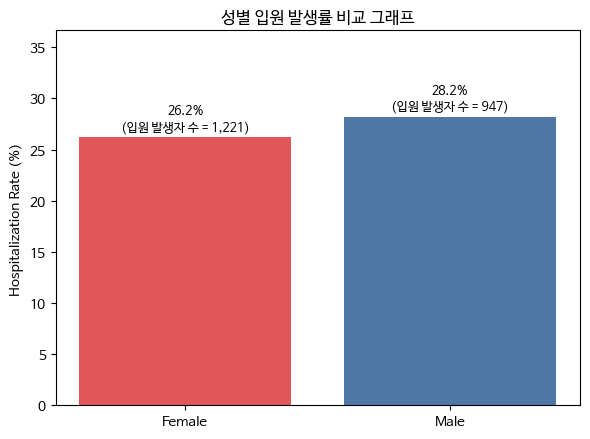

In [13]:
# 성별 입원률 비교 그래프
t = rate_tab(sex_df, 'patient_sex', 'is_hospitalized')
_, p, _, _ = chi2_contingency(pd.crosstab(sex_df['patient_sex'], sex_df['is_hospitalized']))

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(t.index, t['rate'], color=['#e15759', '#4e79a7'])
hospitalization_count = (sex_df[sex_df['is_hospitalized'] == True].groupby('patient_sex').size().reindex(t.index, fill_value=0))
for b, hospitalization in zip(bars, hospitalization_count):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height()}%\n(입원 발생자 수 = {hospitalization:,})", ha='center', va='bottom', fontsize=9)
ax.set_title('성별 입원 발생률 비교 그래프')
ax.set_ylabel('Hospitalization Rate (%)'); ax.set_ylim(0, t['rate'].max()*1.3)
plt.tight_layout(); plt.show()

In [14]:
sex_df = df_A[df_A['patient_sex'].isin(['Male', 'Female'])]
test_association(sex_df, 'patient_sex', 'is_hospitalized')

── patient_sex vs is_hospitalized ──
교차표(관측):
is_hospitalized  False  True 
patient_sex                  
Female            3438   1221
Male              2415    947 

기대빈도 최소값: 908.7  (5 이상이어야 카이제곱 신뢰 가능)
카이제곱  chi2 = 3.706,  dof = 1,  p = 0.0542
효과크기  Cramér's V = 0.021
오즈비   OR(Male vs Female, True) = 1.10

판정: p >= 0.05 → 연관 있다고 보기 어려움


{'chi2': np.float64(3.706456996214772),
 'p': np.float64(0.0542023298808305),
 'dof': 1,
 'cramers_v': np.float64(0.021496374751160032)}

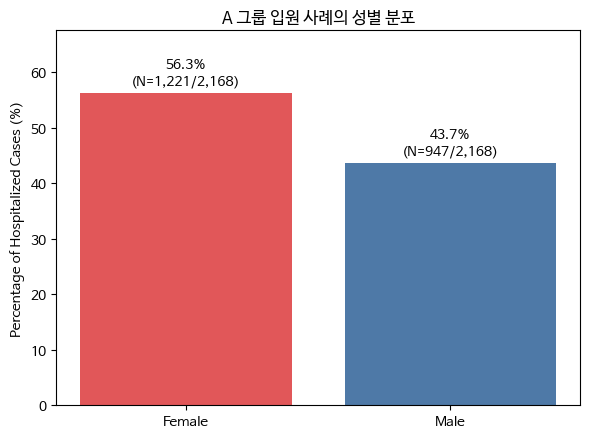

In [15]:
# 입원 사례의 성별 분포
hospital_df = df_A[(df_A['is_hospitalized'] == True) & (df_A['patient_sex'].isin(['Female', 'Male']))]
sex_dist = pd.DataFrame({
    'Count': hospital_df['patient_sex'].value_counts().reindex(['Female', 'Male']),
    'Percent (%)': (hospital_df['patient_sex'].value_counts(normalize=True).reindex(['Female', 'Male']) * 100).round(1)
})
color_map = {'Female': '#e15759', 'Male': '#4e79a7'}
colors = [color_map[s] for s in sex_dist.index]

fig, ax = plt.subplots(figsize=(6,4.5))
bars = ax.bar(sex_dist.index, sex_dist['Percent (%)'], color=colors)
total_hospitalization = sex_dist['Count'].sum()
for bar, count, pct in zip(bars, sex_dist['Count'], sex_dist['Percent (%)']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{pct:.1f}%\n(N={count:,}/{total_hospitalization:,})', ha='center', va='bottom', fontsize=10)
ax.set_title('A 그룹 입원 사례의 성별 분포')
ax.set_ylabel('Percentage of Hospitalized Cases (%)')
ax.set_ylim(0, sex_dist['Percent (%)'].max()*1.2)
plt.tight_layout()
plt.show()

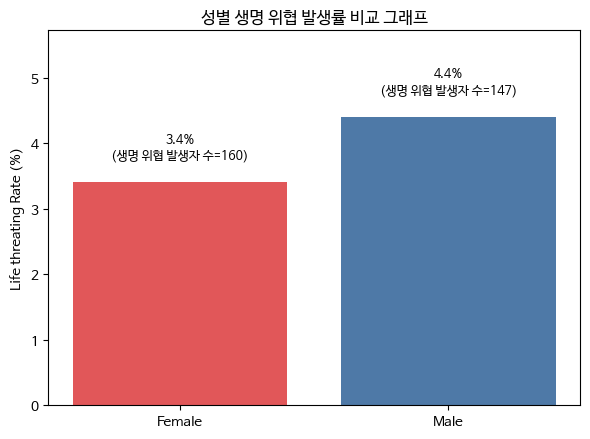

In [16]:
# 성별 생명 위협 발생률 비교 그래프
t = rate_tab(sex_df, 'patient_sex', 'is_life_threat')
_, p, _, _ = chi2_contingency(pd.crosstab(sex_df['patient_sex'], sex_df['is_life_threat']))

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(t.index, t['rate'], color=['#e15759', '#4e79a7'])
threatened_count = (sex_df[sex_df['is_life_threat'] == True].groupby('patient_sex').size().reindex(t.index, fill_value=0))
for b, threatend in zip(bars, threatened_count):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height()}%\n(생명 위협 발생자 수={threatend:,})", ha='center', va='bottom', fontsize=9)
ax.set_title('성별 생명 위협 발생률 비교 그래프')
ax.set_ylabel('Life threating Rate (%)'); ax.set_ylim(0, t['rate'].max()*1.3)
plt.tight_layout(); plt.show()

In [17]:
sex_df = df_A[df_A['patient_sex'].isin(['Male', 'Female'])]
test_association(sex_df, 'patient_sex', 'is_life_threat')

── patient_sex vs is_life_threat ──
교차표(관측):
is_life_threat  False  True 
patient_sex                 
Female           4499    160
Male             3215    147 

기대빈도 최소값: 128.7  (5 이상이어야 카이제곱 신뢰 가능)
카이제곱  chi2 = 4.418,  dof = 1,  p = 0.0356
효과크기  Cramér's V = 0.023
오즈비   OR(Male vs Female, True) = 1.29

판정: p < 0.05 → 연관 있음(귀무가설 기각)


{'chi2': np.float64(4.418174183888048),
 'p': np.float64(0.03555806479698525),
 'dof': 1,
 'cramers_v': np.float64(0.02346967948473787)}

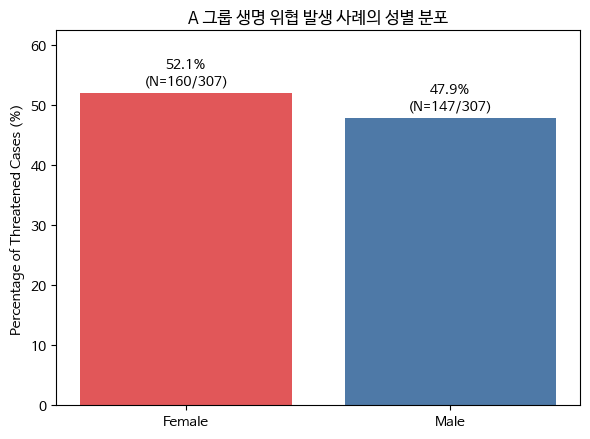

In [18]:
# 생명위협 사례의 성별 분포
threatened_df = df_A[(df_A['is_life_threat'] == True) & (df_A['patient_sex'].isin(['Female', 'Male']))]
sex_dist = pd.DataFrame({
    'Count': threatened_df['patient_sex'].value_counts().reindex(['Female', 'Male']),
    'Percent (%)': (threatened_df['patient_sex'].value_counts(normalize=True).reindex(['Female', 'Male']) * 100).round(1)
})
color_map = {'Female': '#e15759', 'Male': '#4e79a7'}
colors = [color_map[s] for s in sex_dist.index]

fig, ax = plt.subplots(figsize=(6,4.5))
bars = ax.bar(sex_dist.index, sex_dist['Percent (%)'], color=colors)
total_threatened = sex_dist['Count'].sum()
for bar, count, pct in zip(bars, sex_dist['Count'], sex_dist['Percent (%)']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{pct:.1f}%\n(N={count:,}/{total_threatened:,})', ha='center', va='bottom', fontsize=10)
ax.set_title('A 그룹 생명 위협 발생 사례의 성별 분포')
ax.set_ylabel('Percentage of Threatened Cases (%)')
ax.set_ylim(0, sex_dist['Percent (%)'].max()*1.2)
plt.tight_layout()
plt.show()

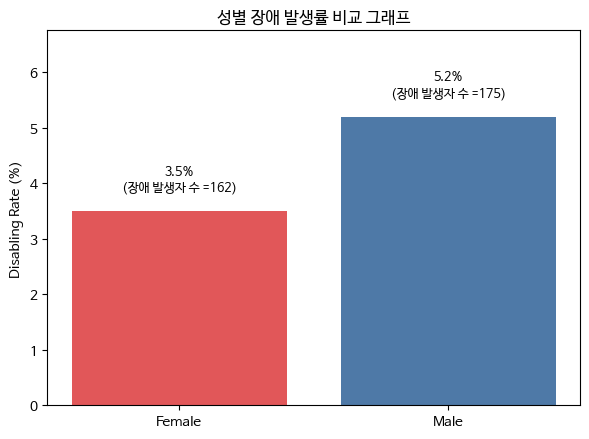

In [19]:
# 성별 장애 발생률 비교 그래프
t = rate_tab(sex_df, 'patient_sex', 'is_disabling')
_, p, _, _ = chi2_contingency(pd.crosstab(sex_df['patient_sex'], sex_df['is_disabling']))

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(t.index, t['rate'], color=['#e15759', '#4e79a7'])
disabled_count = (sex_df[sex_df['is_disabling'] == True].groupby('patient_sex').size().reindex(t.index, fill_value=0))
for b, disabled in zip(bars, disabled_count):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height()}%\n(장애 발생자 수 ={disabled:,})", ha='center', va='bottom', fontsize=9)
ax.set_title('성별 장애 발생률 비교 그래프')
ax.set_ylabel('Disabling Rate (%)'); ax.set_ylim(0, t['rate'].max()*1.3)
plt.tight_layout(); plt.show()

In [20]:
sex_df = df_A[df_A['patient_sex'].isin(['Male', 'Female'])]
test_association(sex_df, 'patient_sex', 'is_disabling')

── patient_sex vs is_disabling ──
교차표(관측):
is_disabling  False  True 
patient_sex               
Female         4497    162
Male           3187    175 

기대빈도 최소값: 141.3  (5 이상이어야 카이제곱 신뢰 가능)
카이제곱  chi2 = 14.063,  dof = 1,  p = 0.000177
효과크기  Cramér's V = 0.042
오즈비   OR(Male vs Female, True) = 1.52

판정: p < 0.05 → 연관 있음(귀무가설 기각)


{'chi2': np.float64(14.062767290353484),
 'p': np.float64(0.00017680944008711705),
 'dof': 1,
 'cramers_v': np.float64(0.041871752372232306)}

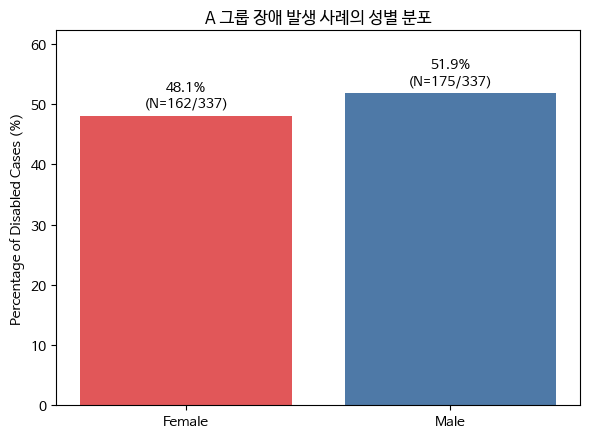

In [21]:
# 장애발생 사례의 성별 분포
disabled_df = df_A[(df_A['is_disabling'] == True) & (df_A['patient_sex'].isin(['Female', 'Male']))]
sex_dist = pd.DataFrame({
    'Count': disabled_df['patient_sex'].value_counts().reindex(['Female', 'Male']),
    'Percent (%)': (disabled_df['patient_sex'].value_counts(normalize=True).reindex(['Female', 'Male']) * 100).round(1)
})
color_map = {'Female': '#e15759', 'Male': '#4e79a7'}
colors = [color_map[s] for s in sex_dist.index]

fig, ax = plt.subplots(figsize=(6,4.5))
bars = ax.bar(sex_dist.index, sex_dist['Percent (%)'], color=colors)
total_disabled = sex_dist['Count'].sum()
for bar, count, pct in zip(bars, sex_dist['Count'], sex_dist['Percent (%)']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{pct:.1f}%\n(N={count:,}/{total_disabled:,})', ha='center', va='bottom', fontsize=10)
ax.set_title('A 그룹 장애 발생 사례의 성별 분포')
ax.set_ylabel('Percentage of Disabled Cases (%)')
ax.set_ylim(0, sex_dist['Percent (%)'].max()*1.2)
plt.tight_layout()
plt.show()

In [22]:
# 소아군 통합 (표본 안정화 -> 카이제곱 기대빈도 문제 해결)
def merge_pediatric(a):
    if a in ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)']:
        return 'Pediatric(0-18)'
    return a

age_order = ['Pediatric(0-18)', 'Adult(19-40)', 'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']
age_df = df_A[df_A['age_group'] != 'Unknown'].copy()
age_df['age_group'] = pd.Categorical(age_df['age_group'].map(merge_pediatric),
                                     categories=age_order, ordered=True)

# rate_tab이 Categorical과 충돌 안 하게 observed=True 버전으로 갱신
def rate_tab(data, col, outcome):
    t = data.groupby(col, observed=True)[outcome].agg(['mean', 'count'])
    t['rate'] = (t['mean'] * 100).round(1)
    return t

/tmp/ipykernel_997/3799200365.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(age_dist.index, rotation=20, ha='right')


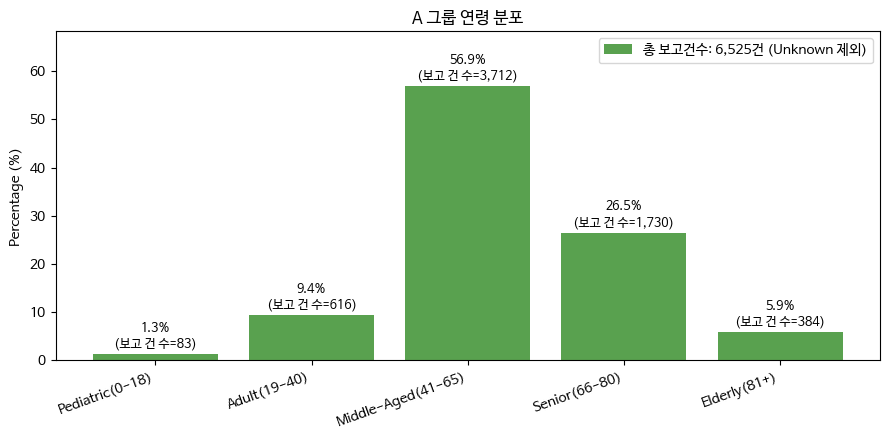

In [23]:
# 연령 분포 비교 그래프 (Unknown 제외)
age_dist = pd.DataFrame({
    'Count': age_df['age_group'].value_counts().reindex(age_order),
    'Percent (%)': (age_df['age_group'].value_counts(normalize=True).reindex(age_order) * 100).round(1)
})
total_age = age_dist['Count'].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(age_dist.index, age_dist['Percent (%)'], color='#59a14f',
              label=f'총 보고건수: {total_age:,}건 (Unknown 제외)')
for bar, count, pct in zip(bars, age_dist['Count'], age_dist['Percent (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%\n(보고 건 수={count:,})', ha='center', va='bottom', fontsize=9)
ax.set_title('A 그룹 연령 분포')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(age_dist.index, rotation=20, ha='right')
ax.set_ylim(0, age_dist['Percent (%)'].max() * 1.2)
ax.legend()
plt.tight_layout(); plt.show()

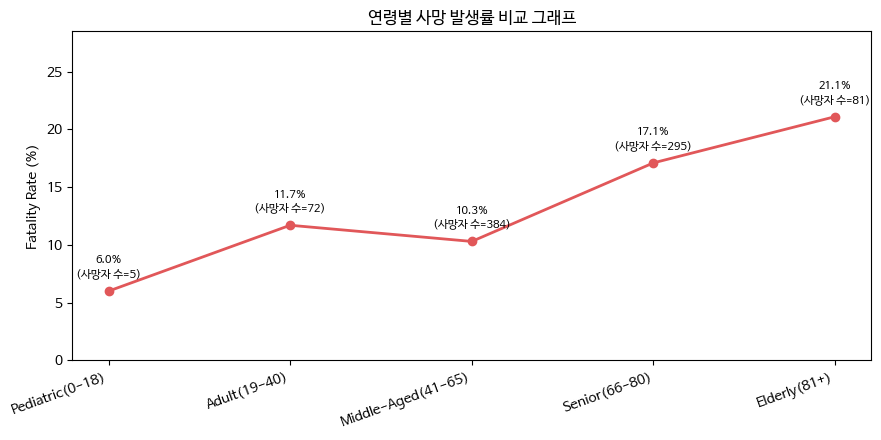

In [24]:
# 연령별 사망 발생률 비교 그래프 - 카이제곱 사용
t = rate_tab(age_df, 'age_group', 'is_fatal').reindex(age_order)
_, p, _, _ = chi2_contingency(pd.crosstab(age_df['age_group'], age_df['is_fatal']))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(len(age_order)), t['rate'], marker='o', color='#e15759', linewidth=2)
death_count = (age_df[age_df['is_fatal'] == True].groupby('age_group', observed=True).size().reindex(age_order, fill_value=0))
for i, (rate, death) in enumerate(zip(t['rate'], death_count)):
    ax.annotate(f"{rate:.1f}%\n(사망자 수={death:,})", (i, rate),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)
ax.set_title('연령별 사망 발생률 비교 그래프')
ax.set_ylabel('Fatality Rate (%)')
ax.set_xticks(range(len(age_order)))
ax.set_xticklabels(age_order, rotation=20, ha='right')
ax.set_ylim(0, t['rate'].max() * 1.35)
plt.tight_layout(); plt.show()

In [25]:
test_association(age_df, 'age_group', 'is_fatal')

── age_group vs is_fatal ──
교차표(관측):
is_fatal            False  True 
age_group                       
Pediatric(0-18)        78      5
Adult(19-40)          544     72
Middle-Aged(41-65)   3328    384
Senior(66-80)        1435    295
Elderly(81+)          303     81 

기대빈도 최소값: 10.6  (5 이상이어야 카이제곱 신뢰 가능)
카이제곱  chi2 = 75.687,  dof = 4,  p = 1.43e-15
효과크기  Cramér's V = 0.108

판정: p < 0.05 → 연관 있음(귀무가설 기각)


{'chi2': np.float64(75.68724848390842),
 'p': np.float64(1.4257473097142778e-15),
 'dof': 4,
 'cramers_v': np.float64(0.10770133848615858)}

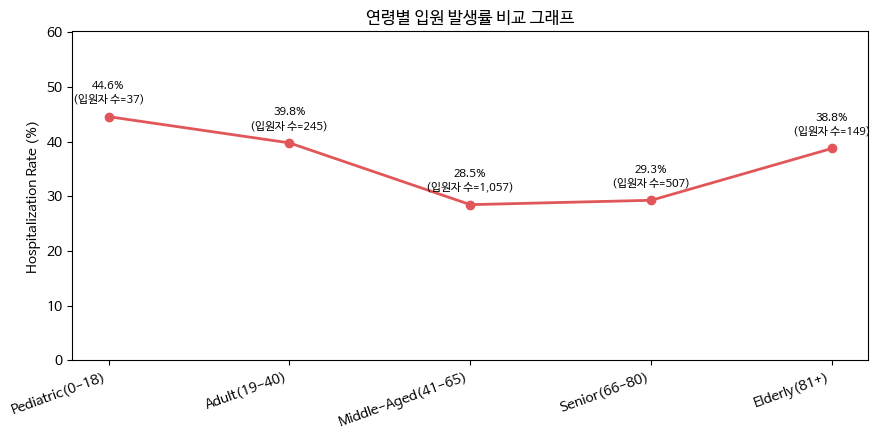

In [26]:
# 연령별 입원 발생률 비교 그래프 - 카이제곱 사용
t = rate_tab(age_df, 'age_group', 'is_hospitalized').reindex(age_order)
_, p, _, _ = chi2_contingency(pd.crosstab(age_df['age_group'], age_df['is_hospitalized']))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(len(age_order)), t['rate'], marker='o', color='#e15759', linewidth=2)
hospitalized_count = (age_df[age_df['is_hospitalized'] == True].groupby('age_group', observed=True).size().reindex(age_order, fill_value=0))
for i, (rate, hospitalized) in enumerate(zip(t['rate'], hospitalized_count)):
    ax.annotate(f"{rate:.1f}%\n(입원자 수={hospitalized:,})", (i, rate),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)
ax.set_title('연령별 입원 발생률 비교 그래프')
ax.set_ylabel('Hospitalization Rate (%)')
ax.set_xticks(range(len(age_order)))
ax.set_xticklabels(age_order, rotation=20, ha='right')
ax.set_ylim(0, t['rate'].max() * 1.35)
plt.tight_layout(); plt.show()

In [27]:
test_association(age_df, 'age_group', 'is_hospitalized')

── age_group vs is_hospitalized ──
교차표(관측):
is_hospitalized     False  True 
age_group                       
Pediatric(0-18)        46     37
Adult(19-40)          371    245
Middle-Aged(41-65)   2655   1057
Senior(66-80)        1223    507
Elderly(81+)          235    149 

기대빈도 최소값: 25.4  (5 이상이어야 카이제곱 신뢰 가능)
카이제곱  chi2 = 53.485,  dof = 4,  p = 6.75e-11
효과크기  Cramér's V = 0.091

판정: p < 0.05 → 연관 있음(귀무가설 기각)


{'chi2': np.float64(53.4848691091499),
 'p': np.float64(6.746100557155852e-11),
 'dof': 4,
 'cramers_v': np.float64(0.09053681464465152)}

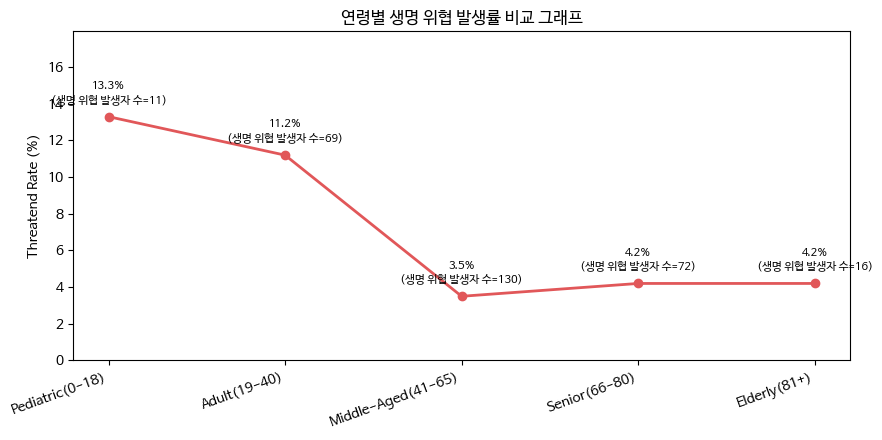

In [28]:
# 연령별 생명위협 발생률 비교 그래프 - 카이제곱 사용
t = rate_tab(age_df, 'age_group', 'is_life_threat').reindex(age_order)
_, p, _, _ = chi2_contingency(pd.crosstab(age_df['age_group'], age_df['is_life_threat']))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(len(age_order)), t['rate'], marker='o', color='#e15759', linewidth=2)
threatend_count = (age_df[age_df['is_life_threat'] == True].groupby('age_group', observed=True).size().reindex(age_order, fill_value=0))
for i, (rate, threatend) in enumerate(zip(t['rate'], threatend_count)):
    ax.annotate(f"{rate:.1f}%\n(생명 위협 발생자 수={threatend:,})", (i, rate),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)
ax.set_title('연령별 생명 위협 발생률 비교 그래프')
ax.set_ylabel('Threatend Rate (%)')
ax.set_xticks(range(len(age_order)))
ax.set_xticklabels(age_order, rotation=20, ha='right')
ax.set_ylim(0, t['rate'].max() * 1.35)
plt.tight_layout(); plt.show()

In [29]:
test_association(age_df, 'age_group', 'is_life_threat')

── age_group vs is_life_threat ──
교차표(관측):
is_life_threat      False  True 
age_group                       
Pediatric(0-18)        72     11
Adult(19-40)          547     69
Middle-Aged(41-65)   3582    130
Senior(66-80)        1658     72
Elderly(81+)          368     16 

기대빈도 최소값: 3.8  (5 이상이어야 카이제곱 신뢰 가능)
카이제곱  chi2 = 87.024,  dof = 4,  p = 5.64e-18
효과크기  Cramér's V = 0.115

판정: p < 0.05 → 연관 있음(귀무가설 기각)


{'chi2': np.float64(87.02409014531924),
 'p': np.float64(5.642044103627813e-18),
 'dof': 4,
 'cramers_v': np.float64(0.11548603945770877)}

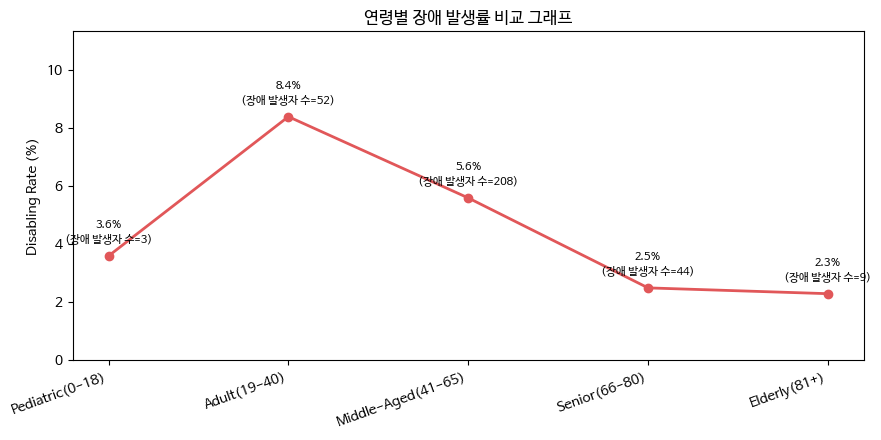

In [30]:
# 연령별 장애 발생률 비교 그래프 - 카이제곱 사용
t = rate_tab(age_df, 'age_group', 'is_disabling').reindex(age_order)
_, p, _, _ = chi2_contingency(pd.crosstab(age_df['age_group'], age_df['is_disabling']))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(len(age_order)), t['rate'], marker='o', color='#e15759', linewidth=2)
disabled_count = (age_df[age_df['is_disabling'] == True].groupby('age_group', observed=True).size().reindex(age_order, fill_value=0))
for i, (rate, disabled) in enumerate(zip(t['rate'], disabled_count)):
    ax.annotate(f"{rate:.1f}%\n(장애 발생자 수={disabled:,})", (i, rate),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)
ax.set_title('연령별 장애 발생률 비교 그래프')
ax.set_ylabel('Disabling Rate (%)')
ax.set_xticks(range(len(age_order)))
ax.set_xticklabels(age_order, rotation=20, ha='right')
ax.set_ylim(0, t['rate'].max() * 1.35)
plt.tight_layout(); plt.show()

In [31]:
test_association(age_df, 'age_group', 'is_disabling')

── age_group vs is_disabling ──
교차표(관측):
is_disabling        False  True 
age_group                       
Pediatric(0-18)        80      3
Adult(19-40)          564     52
Middle-Aged(41-65)   3504    208
Senior(66-80)        1686     44
Elderly(81+)          375      9 

기대빈도 최소값: 4.0  (5 이상이어야 카이제곱 신뢰 가능)
카이제곱  chi2 = 47.297,  dof = 4,  p = 1.32e-09
효과크기  Cramér's V = 0.085

판정: p < 0.05 → 연관 있음(귀무가설 기각)


{'chi2': np.float64(47.297109278976365),
 'p': np.float64(1.3223751303704828e-09),
 'dof': 4,
 'cramers_v': np.float64(0.0851387052004831)}

n=18045, chi2=4165.19, dof=3, p=0, Cramér's V=0.480


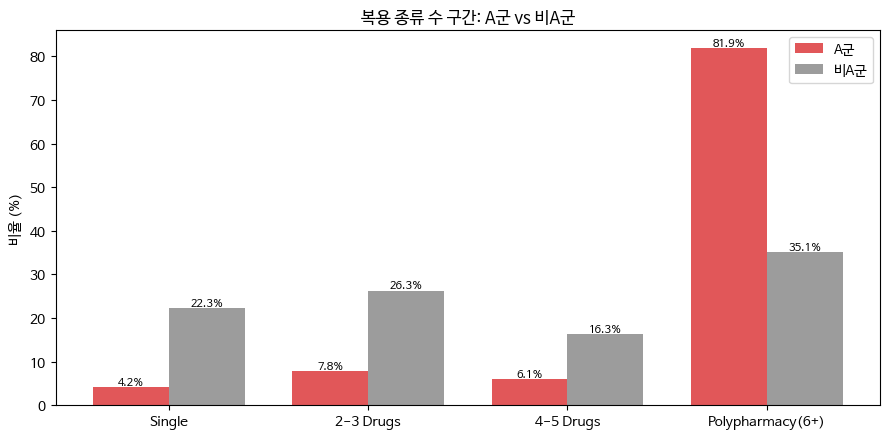

In [32]:
# A군 vs 비A군 복용약물수 구간 분포 비교
df['grp'] = np.where(df['WHO_ATC'] == 'A', 'A군', '비A군')
dc_order = ['Single', '2-3 Drugs', '4-5 Drugs', 'Polypharmacy(6+)']
d2 = df[df['drug_count_category'].isin(dc_order)].copy()
d2['drug_count_category'] = pd.Categorical(d2['drug_count_category'], categories=dc_order, ordered=True)

ct2 = pd.crosstab(d2['grp'], d2['drug_count_category'])
chi2_2, p_2, dof_2, exp_2 = chi2_contingency(ct2)
n2 = ct2.values.sum()
cv2 = np.sqrt(chi2_2 / (n2 * (min(ct2.shape) - 1)))
print(f"n={n2}, chi2={chi2_2:.2f}, dof={dof_2}, p={p_2:.3g}, Cramér's V={cv2:.3f}")

pct2 = ct2.div(ct2.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(dc_order)); w = 0.38
ax.bar(x - w/2, pct2.loc['A군'], w, label='A군', color='#e15759')
ax.bar(x + w/2, pct2.loc['비A군'], w, label='비A군', color='#9c9c9c')
for i, cat in enumerate(dc_order):
    ax.text(i - w/2, pct2.loc['A군', cat] + 0.5, f"{pct2.loc['A군', cat]:.1f}%", ha='center', fontsize=8)
    ax.text(i + w/2, pct2.loc['비A군', cat] + 0.5, f"{pct2.loc['비A군', cat]:.1f}%", ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(dc_order)
ax.set_ylabel('비율 (%)'); ax.set_title('복용 종류 수 구간: A군 vs 비A군')
ax.legend(); plt.tight_layout(); plt.show()

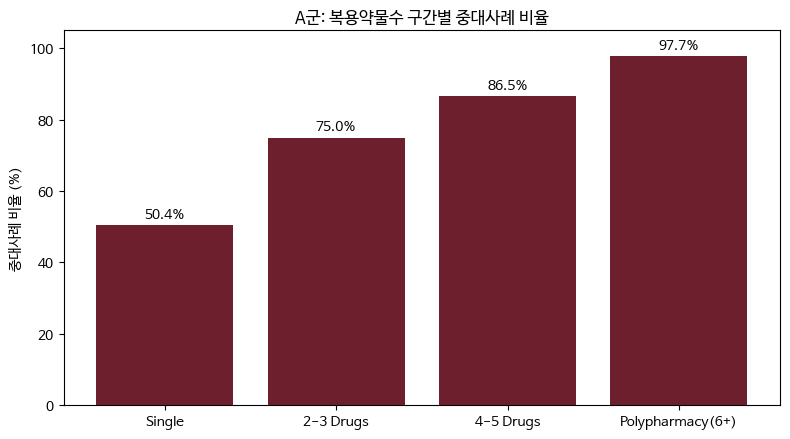

In [33]:
# A군 내부: 복용약물수 구간별 중대사례 비율
serious_by_dc_A = (df_A[df_A['drug_count_category'].isin(dc_order)]
                    .assign(drug_count_category=lambda x: pd.Categorical(
                        x['drug_count_category'], categories=dc_order, ordered=True))
                    .groupby('drug_count_category', observed=True)['serious']
                    .apply(lambda s: (s == 'Yes').mean() * 100))
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(serious_by_dc_A.index, serious_by_dc_A.values, color='#6d1f2e')
for bar, val in zip(bars, serious_by_dc_A.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('A군: 복용약물수 구간별 중대사례 비율')
ax.set_ylabel('중대사례 비율 (%)')
ax.set_ylim(0, 105)
plt.tight_layout(); plt.show()

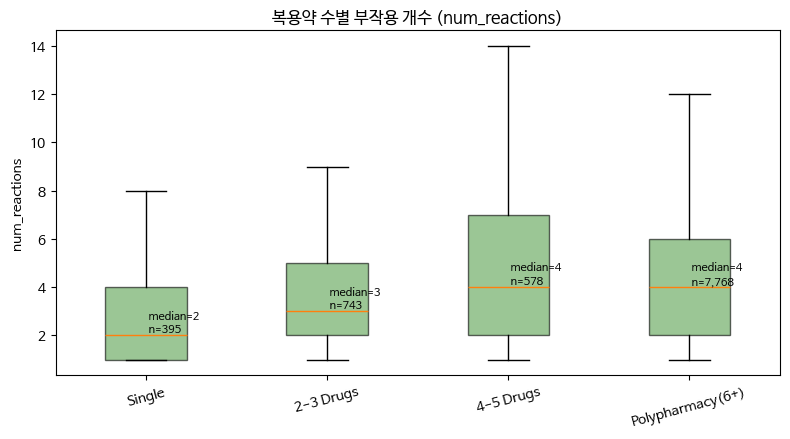

In [34]:
# 복용약 수별 부작용 개수 + Kruskal-Wallis
dc_df = df_A[df_A['drug_count_category'].isin(dc_order)].copy()
dc_df['drug_count_category'] = pd.Categorical(dc_df['drug_count_category'], categories=dc_order, ordered=True)

groups = [dc_df[dc_df['drug_count_category'] == c]['num_reactions'].values for c in dc_order]
fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot(groups, tick_labels=dc_order, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#59a14f'); patch.set_alpha(0.6)
for i, c in enumerate(dc_order, start=1):
    v = dc_df[dc_df['drug_count_category'] == c]['num_reactions']
    ax.text(i, v.median(), f' median={v.median():.0f}\n n={len(v):,}', va='bottom', fontsize=8)
ax.set_title('복용약 수별 부작용 개수 (num_reactions)')
ax.set_ylabel('num_reactions'); ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

In [35]:
def test_kruskal(data, group_col, value_col):
    """
    연속형 value_col이 group_col에 따라 다른지 검정 (비모수 ANOVA).
    - Kruskal-Wallis H: 그룹 간 분포 차이가 '있는지'
    - epsilon-squared: '얼마나 센지' (효과크기, 0~1)
    """
    groups = [g[value_col].values for _, g in data.groupby(group_col, observed=True)]
    H, p = kruskal(*groups)
    n = len(data); k = len(groups)
    epsilon_sq = (H - k + 1) / (n - k)

    print(f"── {group_col} vs {value_col} (Kruskal-Wallis) ──")
    print(data.groupby(group_col, observed=True)[value_col].agg(['count', 'median', 'mean']).round(2), "\n")
    print(f"H = {H:.2f},  p = {p:.3g}")
    print(f"효과크기  epsilon² = {epsilon_sq:.4f}")
    print(f"판정: p {'<' if p < 0.05 else '>='} 0.05 → "
          f"{'그룹 간 차이 있음' if p < 0.05 else '차이 있다고 보기 어려움'}")
    return {'H': H, 'p': p, 'epsilon_sq': epsilon_sq}

test_kruskal(dc_df, 'drug_count_category', 'num_reactions')

── drug_count_category vs num_reactions (Kruskal-Wallis) ──
                     count  median  mean
drug_count_category                     
Single                 395     2.0  2.98
2-3 Drugs              743     3.0  4.35
4-5 Drugs              578     4.0  5.36
Polypharmacy(6+)      7768     4.0  5.26 

H = 205.43,  p = 2.82e-44
효과크기  epsilon² = 0.0214
판정: p < 0.05 → 그룹 간 차이 있음


{'H': np.float64(205.43439358943945),
 'p': np.float64(2.823993422374271e-44),
 'epsilon_sq': np.float64(0.02135383898622779)}

/tmp/ipykernel_997/2193690985.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rates[oc] = d.groupby('drug_count_category', observed=True).apply(


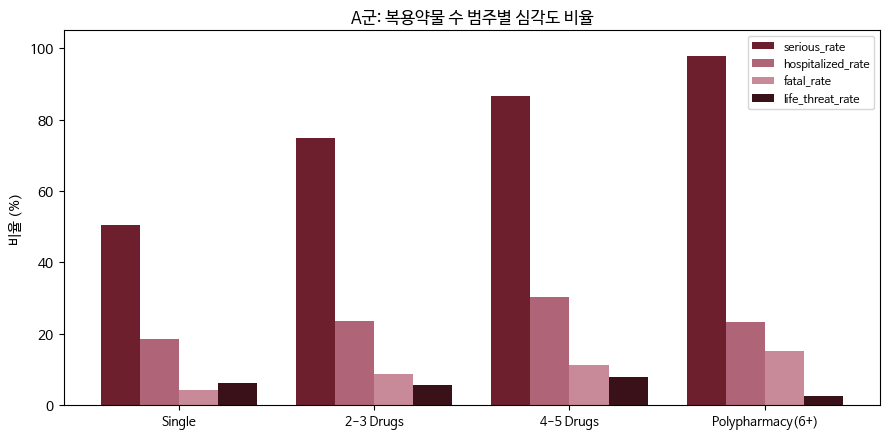

[serious_rate] p=0, Cramér's V=0.441
[hospitalized_rate] p=0.00012, Cramér's V=0.047
[fatal_rate] p=3.1e-13, Cramér's V=0.080
[life_threat_rate] p=1.5e-17, Cramér's V=0.093


In [36]:
# 복용 약수 범주별 심각도
d = df_A[df_A['drug_count_category'].isin(dc_order)].copy()
d['drug_count_category'] = pd.Categorical(d['drug_count_category'], categories=dc_order, ordered=True)

outcomes = {'serious': ('serious_rate', '#6d1f2e'),
            'is_hospitalized': ('hospitalized_rate', '#b06478'),
            'is_fatal': ('fatal_rate', '#c88a99'),
            'is_life_threat': ('life_threat_rate', '#3a1119')}

rates = {}
tests = {}
for oc in outcomes:
    if oc == 'serious':
        rates[oc] = d.groupby('drug_count_category', observed=True).apply(
            lambda g: (g[oc] == 'Yes').mean() * 100).reindex(dc_order)
    else:
        rates[oc] = (d.groupby('drug_count_category', observed=True)[oc].mean() * 100).reindex(dc_order)
    ct = pd.crosstab(d['drug_count_category'], d[oc])
    chi2, p, _, _ = chi2_contingency(ct)
    tests[oc] = (p, (chi2 / ct.values.sum()) ** 0.5)

x = np.arange(len(dc_order)); w = 0.2
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (oc, (label, color)) in enumerate(outcomes.items()):
    ax.bar(x + (i - 1.5) * w, rates[oc].values, w, label=label, color=color)
ax.set_xticks(x); ax.set_xticklabels(dc_order, fontsize=9)
ax.set_ylabel('비율 (%)'); ax.set_title('A군: 복용약물 수 범주별 심각도 비율')
ax.legend(fontsize=8); ax.set_ylim(0, 105)
plt.tight_layout(); plt.show()

for oc, (label, _) in outcomes.items():
    p, v = tests[oc]
    print(f"[{label}] p={p:.2g}, Cramér's V={v:.3f}")

In [37]:
# 대표 성분으로 정규화 (성분 개수가 128종임)
def norm_ingredient(x):
    x = str(x).upper()
    for k in ['ESOMEPRAZOLE', 'LANSOPRAZOLE', 'OMEPRAZOLE', 'PANTOPRAZOLE',
              'LOPERAMIDE', 'FAMOTIDINE', 'POLYETHYLENE GLYCOL']:
        if k in x:
            return k
    return 'OTHER'

df_A['ingredient'] = df_A['suspect_drug'].map(norm_ingredient)

ppi_list = ['ESOMEPRAZOLE', 'LANSOPRAZOLE', 'OMEPRAZOLE', 'PANTOPRAZOLE']
df_A['is_ppi'] = np.where(df_A['ingredient'].isin(ppi_list), 'PPI 노출', '비노출')

kidney_kw = ['kidney', 'renal', 'nephr']
df_A['has_kidney'] = df_A['reactions'].str.lower().map(lambda r: any(k in str(r) for k in kidney_kw))

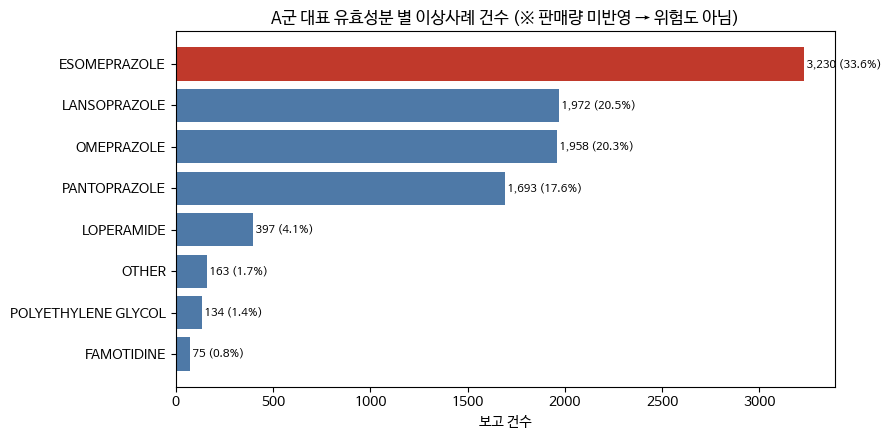

In [38]:
# 성분 TOP 8개 및 분포 균등성 검정
ing = df_A['ingredient'].value_counts()
top_share = ing.iloc[0] / ing.sum() * 100
chi2, p = chisquare(ing.values, [ing.sum()/len(ing)] * len(ing))

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#c0392b' if i == 0 else '#4e79a7' for i in range(len(ing))]
bars = ax.barh(ing.index[::-1], ing.values[::-1], color=colors[::-1])
for i, v in enumerate(ing.values[::-1]):
    ax.text(v, i, f' {v:,} ({v/ing.sum()*100:.1f}%)', va='center', fontsize=8)
ax.set_title('A군 대표 유효성분 별 이상사례 건수 (※ 판매량 미반영 → 위험도 아님)')
ax.set_xlabel('보고 건수')
plt.tight_layout(); plt.show()

In [39]:
# 성분 분포 균등성 검정 결과 (위 셀의 chi2, p, ing, top_share 사용)
print(f"[성분 분포 균등성] Chi-square 적합도 검정 chi2={chi2:.1f}, p={p:.2g}")
print(f"최다 성분({ing.index[0]}) 점유율: {top_share:.2f}%")

[성분 분포 균등성] Chi-square 적합도 검정 chi2=8028.8, p=0
최다 성분(ESOMEPRAZOLE) 점유율: 33.57%


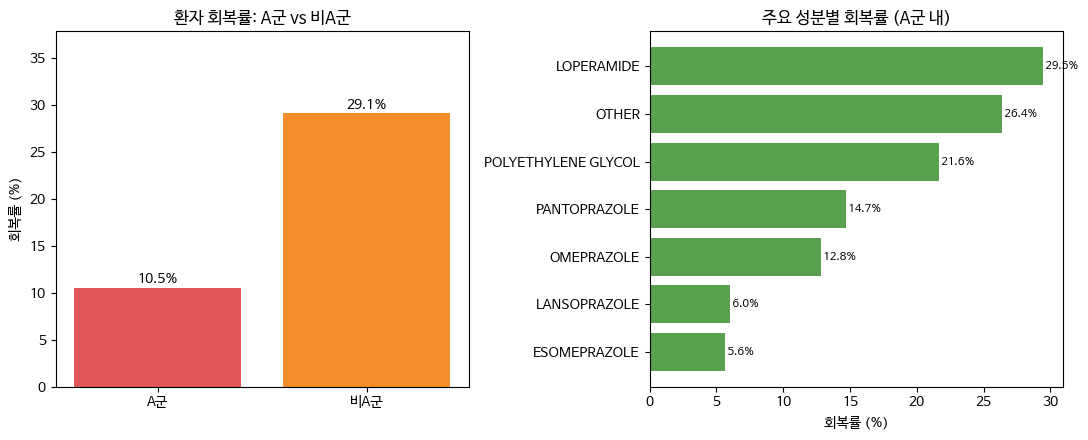

In [40]:
# 환자 회복률: A군 vs 비A군, 성분별 회복률
df['grp'] = np.where(df['WHO_ATC'] == 'A', 'A군', '비A군')

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

rec = df.groupby('grp')['patient_recovered'].mean().reindex(['A군', '비A군']) * 100
ct = pd.crosstab(df['grp'], df['patient_recovered'])
chi2, p, _, _ = chi2_contingency(ct); v = (chi2/ct.values.sum())**0.5
b = ax[0].bar(rec.index, rec.values, color=['#e15759', '#f28e2b'])
for bar, val in zip(b, rec.values):
    ax[0].text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}%', ha='center', fontsize=10)
ax[0].set_title('환자 회복률: A군 vs 비A군'); ax[0].set_ylabel('회복률 (%)'); ax[0].set_ylim(0, rec.max()*1.3)

major = df_A['ingredient'].value_counts(); major = major[major >= 100].index
sub = df_A[df_A['ingredient'].isin(major)]
srec = (sub.groupby('ingredient')['patient_recovered'].mean()*100).sort_values()
b = ax[1].barh(srec.index, srec.values, color='#59a14f')
for i, val in enumerate(srec.values):
    ax[1].text(val, i, f' {val:.1f}%', va='center', fontsize=8)
ax[1].set_title('주요 성분별 회복률 (A군 내)'); ax[1].set_xlabel('회복률 (%)')
plt.tight_layout(); plt.show()

In [41]:
# 회복 여부 통계 검정 결과 (위 셀의 rec, chi2, v 사용)
print(f"[회복 여부] A vs 비A: A군 {rec['A군']:.1f}% vs 비A군 {rec['비A군']:.1f}%")
print(f"  chi2={chi2:.1f}, p<0.001, Cramér's V={v:.3f}")

[회복 여부] A vs 비A: A군 10.5% vs 비A군 29.1%
  chi2=1008.4, p<0.001, Cramér's V=0.235


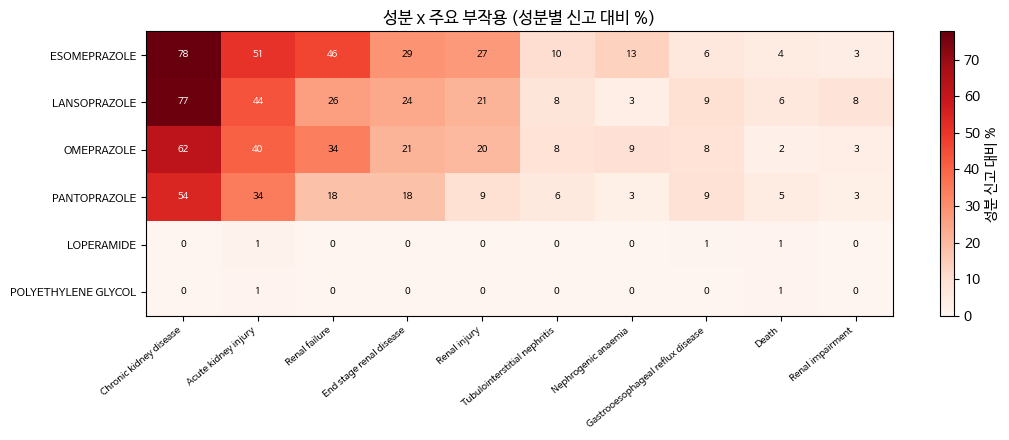

In [42]:
# 성분 x 주요 부작용 히트맵
major = ['ESOMEPRAZOLE', 'LANSOPRAZOLE', 'OMEPRAZOLE', 'PANTOPRAZOLE',
         'LOPERAMIDE', 'POLYETHYLENE GLYCOL']
d = df_A[df_A['ingredient'].isin(major)].copy()

long = d[['ingredient', 'reactions']].copy()
long['reaction'] = long['reactions'].str.split(';')
long = long.explode('reaction'); long['reaction'] = long['reaction'].str.strip()
top_r = long['reaction'].value_counts().head(10).index.tolist()
long = long[long['reaction'].isin(top_r)]

denom = d.groupby('ingredient').size()
mat = (long.groupby(['ingredient', 'reaction']).size().unstack(fill_value=0)
       .div(denom, axis=0).mul(100).reindex(major)[top_r])

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(mat.values, cmap='Reds', aspect='auto')
ax.set_xticks(range(len(top_r))); ax.set_xticklabels(top_r, rotation=40, ha='right', fontsize=7)
ax.set_yticks(range(len(major))); ax.set_yticklabels(major, fontsize=8)
for i in range(len(major)):
    for j in range(len(top_r)):
        val = mat.values[i, j]
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7,
                color='white' if val > 40 else 'black')
plt.colorbar(im, label='성분 신고 대비 %')
ax.set_title('성분 x 주요 부작용 (성분별 신고 대비 %)')
plt.tight_layout(); plt.show()

/tmp/ipykernel_997/3055116650.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rB = df_A.groupby('kidney_lab').apply(lambda g: (g['serious']=='Yes').mean()*100).reindex(['신장 부작용', '그 외 반응'])


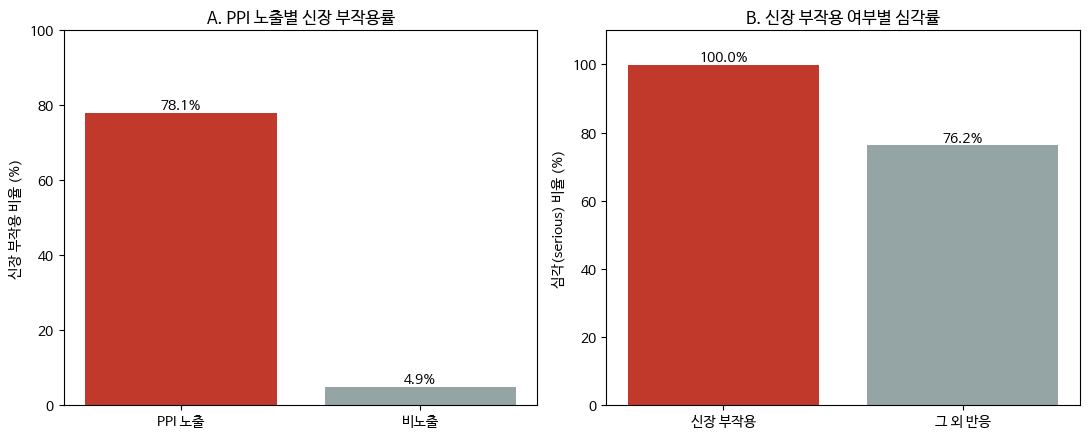

In [43]:
# 검정 A: PPI 노출 -> 신장 부작용 / 검정 B: 신장 부작용 -> 심각도
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

rA = df_A.groupby('is_ppi')['has_kidney'].mean().reindex(['PPI 노출', '비노출']) * 100
ctA = pd.crosstab(df_A['is_ppi'], df_A['has_kidney'])
chi2A, pA, _, _ = chi2_contingency(ctA); vA = (chi2A / ctA.values.sum())**0.5
b = ax[0].bar(rA.index, rA.values, color=['#c0392b', '#95a5a6'])
for bar, v in zip(b, rA.values):
    ax[0].text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontsize=10)
ax[0].set_title('A. PPI 노출별 신장 부작용률'); ax[0].set_ylabel('신장 부작용 비율 (%)'); ax[0].set_ylim(0, 100)

df_A['kidney_lab'] = df_A['has_kidney'].map({True: '신장 부작용', False: '그 외 반응'})
rB = df_A.groupby('kidney_lab').apply(lambda g: (g['serious']=='Yes').mean()*100).reindex(['신장 부작용', '그 외 반응'])
ctB = pd.crosstab(df_A['has_kidney'], df_A['serious'])
chi2B, pB, _, _ = chi2_contingency(ctB); vB = (chi2B / ctB.values.sum())**0.5
b = ax[1].bar(rB.index, rB.values, color=['#c0392b', '#95a5a6'])
for bar, v in zip(b, rB.values):
    ax[1].text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontsize=10)
ax[1].set_title('B. 신장 부작용 여부별 심각률'); ax[1].set_ylabel('심각(serious) 비율 (%)'); ax[1].set_ylim(0, 110)

plt.tight_layout(); plt.show()

In [44]:
print("PPI -> 신장 부작용 -> 심각도 : 통계검정 요약\n")
print(f"[검정 A] PPI x 신장 부작용 -> chi2={chi2A:.0f}, p<0.001, Cramér's V={vA:.2f} (효과크기 큼)")
print(f"  신장 부작용률: PPI 노출 {rA['PPI 노출']:.1f}% vs 비노출 {rA['비노출']:.1f}%")
print(f"[검정 B] 신장 부작용 x 심각 -> chi2={chi2B:.0f}, p<0.001, Cramér's V={vB:.2f} (효과크기 큼)")
print(f"  심각률: 신장 부작용 {rB['신장 부작용']:.1f}% vs 그 외 {rB['그 외 반응']:.1f}%")

PPI -> 신장 부작용 -> 심각도 : 통계검정 요약

[검정 A] PPI x 신장 부작용 -> chi2=1883, p<0.001, Cramér's V=0.44 (효과크기 큼)
  신장 부작용률: PPI 노출 78.1% vs 비노출 4.9%
[검정 B] 신장 부작용 x 심각 -> chi2=1750, p<0.001, Cramér's V=0.43 (효과크기 큼)
  심각률: 신장 부작용 100.0% vs 그 외 76.2%


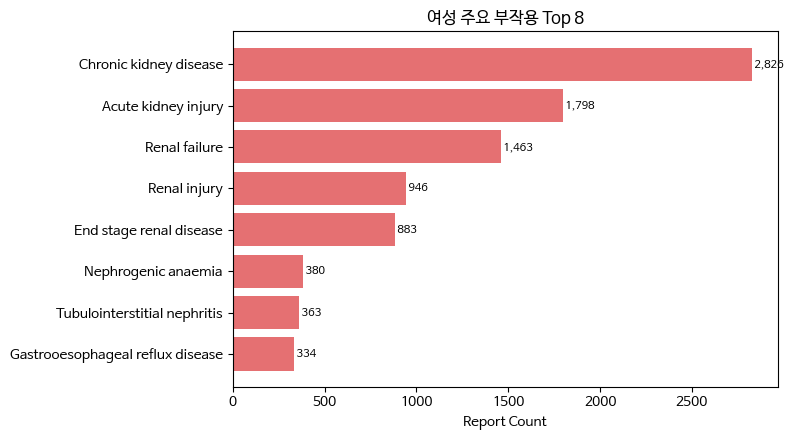

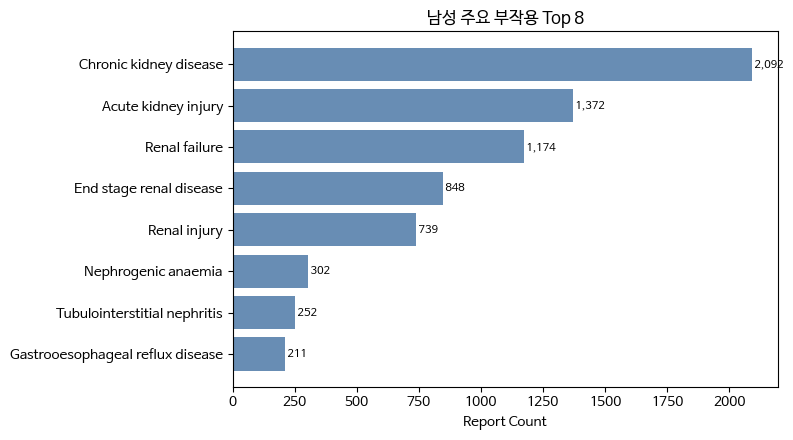

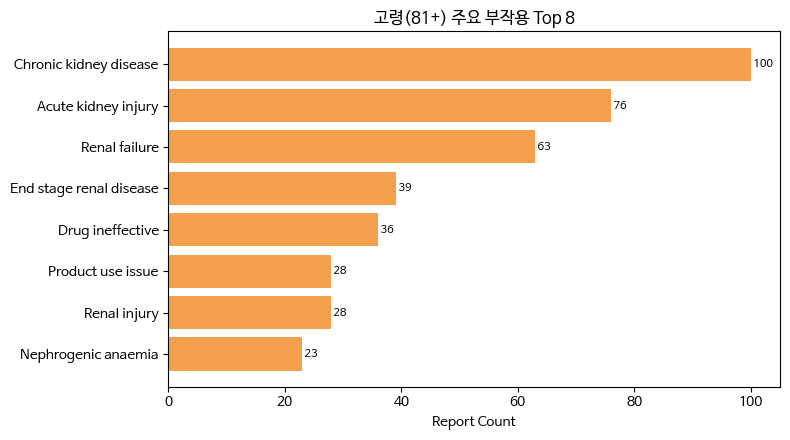

In [45]:
# 여성/남성/고령층 별 주요 부작용 Top8
def top_reactions(data, col, val, n=8):
    sub = data[data[col] == val]
    return sub['reactions'].str.split(';').explode().str.strip().value_counts().head(n)

sex_df = df_A[df_A['patient_sex'].isin(['Male', 'Female'])]
elder_df = df_A[df_A['age_group'] == 'Elderly(81+)']  # 원본 age_group 기준 (통합 전)

targets = [
    ('여성',      sex_df,   'patient_sex', 'Female',       '#e15759'),
    ('남성',      sex_df,   'patient_sex', 'Male',         '#4e79a7'),
    ('고령(81+)', elder_df, 'age_group',   'Elderly(81+)', '#f28e2b'),
]

for label, src, col, val, color in targets:
    tr = top_reactions(src, col, val).sort_values()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(tr.index, tr.values, color=color, alpha=0.85)
    for i, v in enumerate(tr.values):
        ax.text(v, i, f' {v:,}', va='center', fontsize=8)
    ax.set_title(f'{label} 주요 부작용 Top 8')
    ax.set_xlabel('Report Count')
    plt.tight_layout(); plt.show()

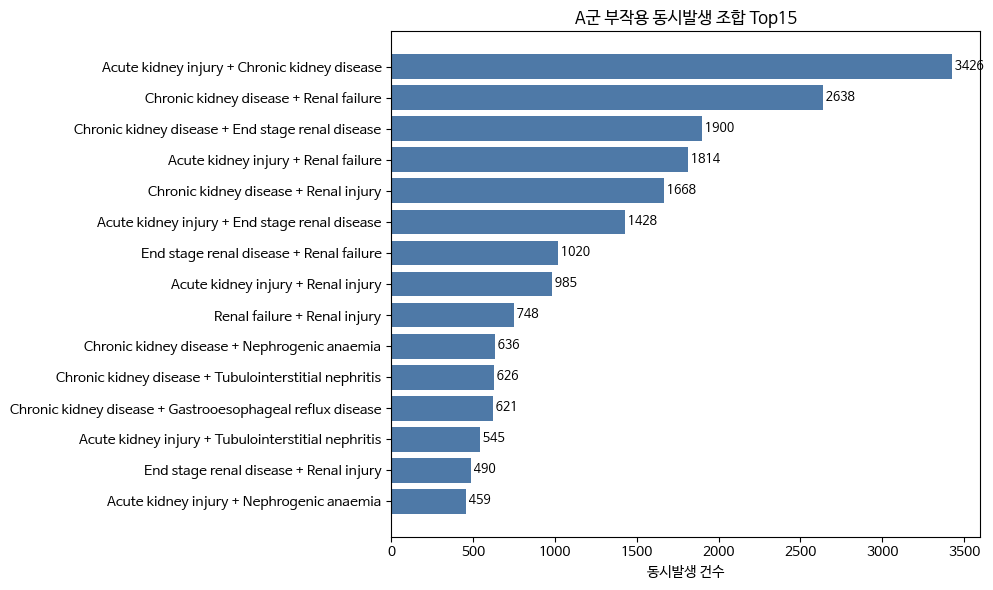

In [46]:
# 부작용 동시발생 조합(co-occurrence) Top15
from itertools import combinations
from collections import Counter

def get_reaction_list(r):
    if pd.isna(r):
        return []
    return [x.strip() for x in str(r).split(';') if x.strip() and x.strip().lower() != 'unknown']

pair_counter = Counter()
for r in df_A['reactions']:
    reactions = sorted(set(get_reaction_list(r)))
    if len(reactions) < 2:
        continue
    for pair in combinations(reactions, 2):
        pair_counter[pair] += 1

top_pairs = pair_counter.most_common(15)
pair_labels = [f"{a} + {b}" for (a, b), _ in top_pairs]
pair_counts = [c for _, c in top_pairs]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pair_labels[::-1], pair_counts[::-1], color='#4e79a7')
for i, v in enumerate(pair_counts[::-1]):
    ax.text(v, i, f' {v}', va='center', fontsize=9)
ax.set_title('A군 부작용 동시발생 조합 Top15')
ax.set_xlabel('동시발생 건수')
plt.tight_layout(); plt.show()

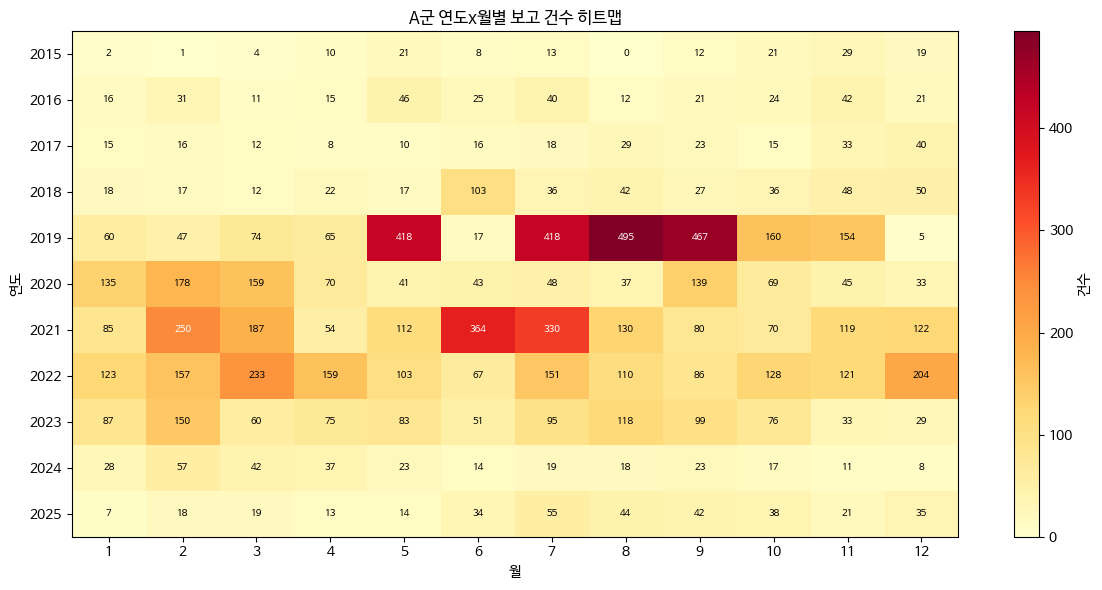

In [47]:
# 2019년 급증 원인 규명 (히트맵)
df_A['year']  = df_A['receive_date'].dt.year
df_A['month'] = df_A['receive_date'].dt.month

heat = df_A.groupby(['year', 'month']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heat.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
ax.set_xlabel('월'); ax.set_ylabel('연도')
ax.set_title('A군 연도x월별 보고 건수 히트맵')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        ax.text(j, i, str(val), ha='center', va='center', fontsize=7,
                color='white' if val > heat.values.max()*0.5 else 'black')
fig.colorbar(im, ax=ax, label='건수')
plt.tight_layout(); plt.show()

[중대사례] chi2=147.82, p=5.19e-34 (유의), Cramér's V=0.124  급증기=99.1% vs 평시=91.7%
[사망] chi2=51.61, p=6.76e-13 (유의), Cramér's V=0.073  급증기=9.4% vs 평시=15.5%
[입원] chi2=146.62, p=9.49e-34 (유의), Cramér's V=0.123  급증기=13.9% vs 평시=26.5%
[생명위협] chi2=68.60, p=1.21e-16 (유의), Cramér's V=0.084  급증기=0.5% vs 평시=4.2%
[장애] chi2=21.80, p=3.02e-06 (유의), Cramér's V=0.048  급증기=1.9% vs 평시=4.1%


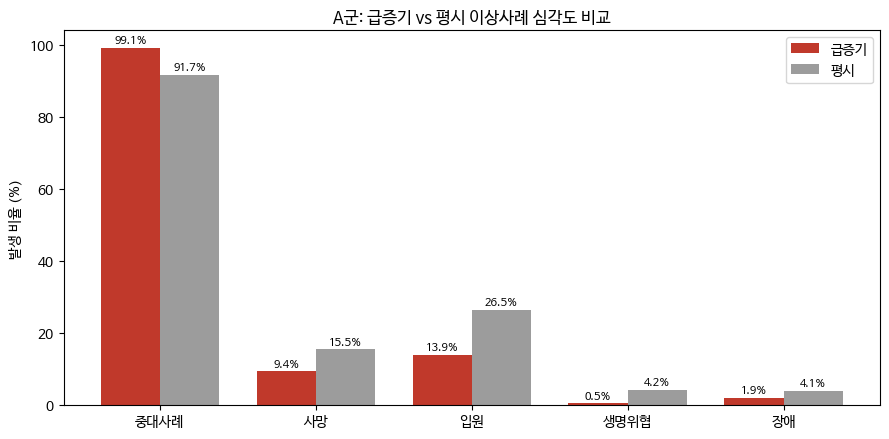

In [48]:
# 급증기 vs 평시 비교 - 그래프 + 통계검정
monthly_flat = df_A.groupby(df_A['receive_date'].dt.to_period('M')).size()
threshold = monthly_flat.mean() + 3 * monthly_flat.std()
spike_periods = monthly_flat[monthly_flat > threshold]

spike_mask = df_A['receive_date'].dt.to_period('M').isin(spike_periods.index)
spike_df = df_A[spike_mask]
rest_df  = df_A[~spike_mask]

df_A['period_group'] = np.where(spike_mask, '급증기', '평시')

metrics = {
    'serious': ('중대사례', lambda d: (d['serious'] == 'Yes')),
    'is_fatal': ('사망', lambda d: d['is_fatal']),
    'is_hospitalized': ('입원', lambda d: d['is_hospitalized']),
    'is_life_threat': ('생명위협', lambda d: d['is_life_threat']),
    'is_disabling': ('장애', lambda d: d['is_disabling']),
}

results = {}
for col, (label, fn) in metrics.items():
    flag = fn(df_A)
    ct = pd.crosstab(df_A['period_group'], flag)
    chi2, p, dof, exp = chi2_contingency(ct)
    n = ct.values.sum()
    cv = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    spike_rate = fn(spike_df).mean() * 100
    rest_rate  = fn(rest_df).mean() * 100
    sig = '유의' if p < 0.05 else '무의미'
    print(f"[{label}] chi2={chi2:.2f}, p={p:.3g} ({sig}), Cramér's V={cv:.3f}  "
          f"급증기={spike_rate:.1f}% vs 평시={rest_rate:.1f}%")
    results[col] = dict(label=label, spike=spike_rate, rest=rest_rate, chi2=chi2, p=p, cv=cv)

labels_kr = [v['label'] for v in results.values()]
spike_vals = [v['spike'] for v in results.values()]
rest_vals  = [v['rest'] for v in results.values()]

x = np.arange(len(labels_kr)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
b1 = ax.bar(x - w/2, spike_vals, w, label='급증기', color='#c0392b')
b2 = ax.bar(x + w/2, rest_vals, w, label='평시', color='#9c9c9c')
for bars, vals in [(b1, spike_vals), (b2, rest_vals)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels_kr)
ax.set_ylabel('발생 비율 (%)')
ax.set_title('A군: 급증기 vs 평시 이상사례 심각도 비교')
ax.legend()
plt.tight_layout(); plt.show()

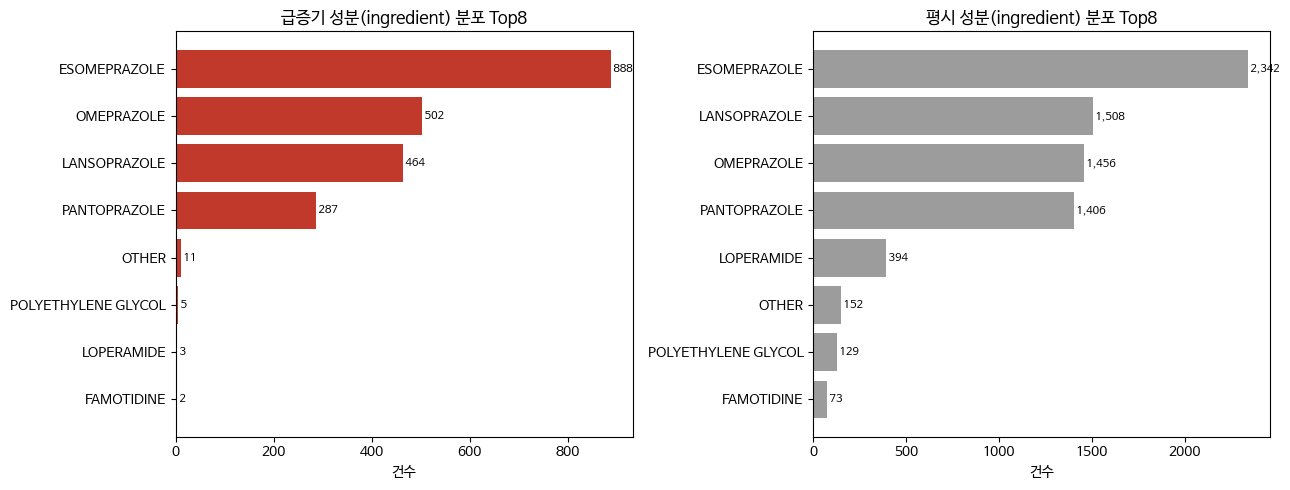


[급증기 vs 평시 성분 분포] chi2=215.65, p=1.27e-44, Cramér's V=0.151
→ p<0.05면 급증기에 특정 성분이 통계적으로 유의하게 몰렸다는 뜻

급증기 최다 성분 'ESOMEPRAZOLE' 점유율: 41.1%
→ 성분 분포는 유의하게 다르지만 특정 성분 집중도는 낮음 → 복합적 요인


In [49]:
# 성분/브랜드 분포 (급증 원인 규명용)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

spike_ing = spike_df['ingredient'].value_counts().head(8)
axes[0].barh(spike_ing.index[::-1], spike_ing.values[::-1], color='#c0392b')
axes[0].set_title('급증기 성분(ingredient) 분포 Top8')
axes[0].set_xlabel('건수')
for i, v in enumerate(spike_ing.values[::-1]):
    axes[0].text(v, i, f' {v:,}', va='center', fontsize=8)

rest_ing = rest_df['ingredient'].value_counts().head(8)
axes[1].barh(rest_ing.index[::-1], rest_ing.values[::-1], color='#9c9c9c')
axes[1].set_title('평시 성분(ingredient) 분포 Top8')
axes[1].set_xlabel('건수')
for i, v in enumerate(rest_ing.values[::-1]):
    axes[1].text(v, i, f' {v:,}', va='center', fontsize=8)

plt.tight_layout(); plt.show()

top_ing_common = list(set(spike_ing.index[:5]) | set(rest_ing.index[:5]))
ct_ing = pd.crosstab(df_A[df_A['ingredient'].isin(top_ing_common)]['period_group'],
                      df_A[df_A['ingredient'].isin(top_ing_common)]['ingredient'])
chi2_ing, p_ing, dof_ing, _ = chi2_contingency(ct_ing)
cv_ing = np.sqrt(chi2_ing / (ct_ing.values.sum() * (min(ct_ing.shape) - 1)))
print(f"\n[급증기 vs 평시 성분 분포] chi2={chi2_ing:.2f}, p={p_ing:.3g}, Cramér's V={cv_ing:.3f}")
print("→ p<0.05면 급증기에 특정 성분이 통계적으로 유의하게 몰렸다는 뜻")

spike_top_share = spike_ing.iloc[0] / len(spike_df) * 100
print(f"\n급증기 최다 성분 '{spike_ing.index[0]}' 점유율: {spike_top_share:.1f}%")
if p_ing < 0.05 and spike_top_share > 60:
    print("→ 특정 성분 집중 + 통계적 유의 → 해당 성분 이슈(리콜/보도) 가능성 높음")
elif p_ing < 0.05:
    print("→ 성분 분포는 유의하게 다르지만 특정 성분 집중도는 낮음 → 복합적 요인")
else:
    print("→ 성분 분포 차이 유의하지 않음 → 시스템적 요인(일괄 보고 접수 등) 가능성")